In [1]:
import sys
sys.path.insert(1, '../src/')
from preprocessing import *

In [2]:
import matplotlib.pyplot as plt
import json

with open('../config.json', 'r') as f:
    config = json.load(f)

RAW_DATA_PATH = config["raw_data_path"]
ELEMENTS_DICT = config["elements_dict"]
N_STD = config["n_std"]
ROW_NR = config["row_nr"]
N_DES = config["n_des"]
N = config["n"]
BUNCH_NO = config["bunch_no"]
TO_FE = config["to_fe"]
KEEP_FE = config["keep_fe"]

### Preprocessing step 

In [3]:
# load raw
raw_df = read_raw_file(RAW_DATA_PATH)

# ensure expected columns selected (elements_dict should be defined in module or imported)
selected = select_expected_columns(raw_df, ELEMENTS_DICT)

# initial rounding and despike
cleaned = round_and_despike_df(selected)

# normalize by elements_dict mapping
normalized = normalize_by_elements_dict(cleaned, ELEMENTS_DICT)

# subtract blank and clip
normalized_blank = subtract_blank_and_clip(normalized)

# optional additional despike passes
despike_df = apply_multiple_despike(normalized_blank)

# sort and create bunches
bunched = sort_and_bunch(despike_df)

# optional normalize to Fe
if False:
    bunched = normalize_to_fe(bunched)

# add names column and return
bunched = add_names_column(bunched, RAW_DATA_PATH)

In [6]:
# equivalent to:
# res = machine(RAW_DATA_PATH, ELEMENTS_DICT)

In [13]:
selected.columns = despike_df.columns
cleaned.columns = despike_df.columns

dfs = [selected, cleaned, normalized, normalized_blank, despike_df, bunched]
preprocessing_steps = ['raw', 'round and despike', 'normalize', 'subtract blank and clip', 'multiple despike', 'bunch']

### Visualisation

In [14]:
el = 'Na'

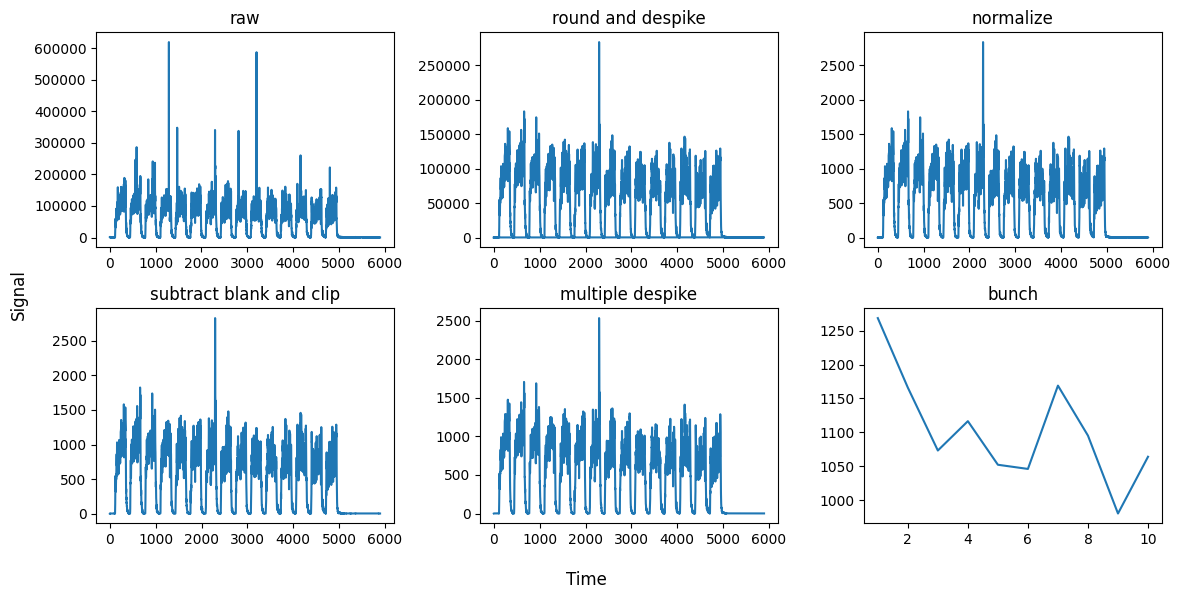

In [15]:
# Create figure and subplots: 2 rows, 3 columns
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(12, 6)
)

# Flatten axes array for easy iteration
axes = axes.flatten()

# Plot each data vector
for i, ax in enumerate(axes):
    ax.plot(dfs[i][el])
    ax.set_title(preprocessing_steps[i])

# Label shared axes
fig.supxlabel('Time')
fig.supylabel('Signal')

# Improve layout
plt.tight_layout()
plt.show()